<!-- colab-badge -->
[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bmnogueira-ufms/IA-2026-02/blob/main/Aulas%20Pr%C3%A1ticas/aula02-regressao-linear/aula02-sklearn.ipynb)

# Aula Prática 02 - Regressão Linear com o scikit-learn

**Inteligência Artificial - Graduação**
Prof. Bruno Nogueira - FACOM/UFMS - 2026/2

---

## Do que trata este notebook

Na aula guiada você **escreveu** a regressão linear: a hipótese, a função de custo, o
gradiente, o laço de treinamento e a normalização. Cinco funções, cerca de quinze
linhas de matemática.

Este notebook faz **exatamente a mesma coisa**, na **mesma base**, com o mesmo
atributo - mas usando o scikit-learn. O objetivo não é substituir o que você
implementou: é mostrar onde cada peça que você escreveu foi parar dentro da
biblioteca, e o que ela ganha de brinde.

Os números têm de bater. Ao longo do notebook há `assert`s comparando os coeficientes
da biblioteca com os valores que a nossa implementação encontrou - se algum falhasse,
uma das duas estaria errada.

### Roteiro

| # | Tema | O que você escreveu na aula |
|---|------|------------------------------|
| 1 | Por que usar uma biblioteca | - |
| 2 | A convenção `X`, `y` do scikit-learn | os vetores `x` e `y` |
| 3 | `LinearRegression` | `gradiente_descendente` |
| 4 | A API `fit` / `predict` / `score` | - |
| 5 | `StandardScaler` | `padroniza` e `desnormaliza` |
| 6 | `Pipeline` | o encadeamento feito à mão |
| 7 | Treino e teste | (aula 01) |
| 8 | Validação cruzada | (aula 01) |
| 9 | `DummyRegressor` | a linha de base da média |
| 10 | `SGDRegressor` | `gradiente_descendente`, de novo |
| 11 | Prevendo para carros novos | `hipotese` |
| 12 | Salvando o modelo treinado | - |

### Como usar este notebook

Este notebook vem **completo e executado**: não há lacunas para preencher. Ele é
material de consulta - a partir daqui, todo modelo que aparecer na disciplina vai
seguir os mesmos três métodos que você vai ver na seção 4.

Os marcadores 🔎 **PARE E PENSE** continuam valendo: são perguntas para responder
antes de rodar a célula seguinte.

---
## 0. Preparando o ambiente

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)
plt.rcParams.update({
    "figure.figsize": (7, 4.2),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

CORES = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

print(f"NumPy       {np.__version__}")
print(f"pandas      {pd.__version__}")
print(f"scikit-learn {sklearn.__version__}")

NumPy       2.4.4
pandas      3.0.2
scikit-learn 1.8.0


---
## 1. Por que usar uma biblioteca?

Vale ser honesto: o código que você escreveu na aula guiada **funciona**. Ele encontrou
os mesmos parâmetros que a solução fechada e o scikit-learn, com quatro casas de
precisão. Não é brinquedo.

Então por que não continuar com ele? Porque o algoritmo é a parte pequena. O que falta
em volta:

| o que falta | por que importa |
|---|---|
| separar treino e teste, validar | sem isso não há como saber se o modelo generaliza |
| um objeto que **guarde** o modelo treinado | para prever amanhã, sem retreinar |
| encadear pré-processamento e modelo | é onde nascem os vazamentos de dados |
| a **mesma interface** para todos os modelos | trocar de algoritmo devia custar uma linha |
| robustez numérica, dados esparsos, paralelismo | problemas de engenharia, não de teoria |

É isso que uma biblioteca oferece. E é por isso que a ordem desta aula foi implementar
primeiro e importar depois: quem começa pelo `import` nunca descobre que existe um
$\alpha$, e não entende por que o modelo não converge.

---
## 2. A base e a convenção `X`, `y`

Mesma base da aula guiada: **Auto MPG**, 398 carros, prevendo o consumo (km/l) a
partir do peso (kg).

In [2]:
CAMINHO_LOCAL = Path("../../dados/auto-mpg.csv")
URL_FALLBACK = ("https://raw.githubusercontent.com/bmnogueira-ufms/IA-2026-02/"
                "main/dados/auto-mpg.csv")

bruto = pd.read_csv(CAMINHO_LOCAL if CAMINHO_LOCAL.exists() else URL_FALLBACK)
carros = bruto.rename(columns={
    "mpg": "consumo_mpg", "cylinders": "cilindros", "displacement": "cilindrada",
    "horsepower": "potencia", "weight": "peso_lb", "acceleration": "aceleracao",
    "model_year": "ano", "origin": "origem", "name": "modelo",
})
carros["peso_kg"] = carros["peso_lb"] * 0.45359237
carros["consumo_kml"] = carros["consumo_mpg"] * 0.4251437

print(f"{carros.shape[0]} carros")
carros[["modelo", "ano", "peso_kg", "consumo_kml"]].head(3)

398 carros


,modelo,ano,peso_kg,consumo_kml
0,chevrolet chevelle malibu,70,1589.387664,7.652587
1,buick skylark 320,70,1675.116622,6.377156
2,plymouth satellite,70,1558.543383,7.652587


Aqui aparece a primeira convenção do scikit-learn, e ela pega muita gente de surpresa:

- **`X` é sempre bidimensional**: uma linha por exemplo, uma coluna por atributo. Mesmo
  com **um único** atributo, `X` tem forma `(m, 1)` - não `(m,)`.
- **`y` é unidimensional**: forma `(m,)`.

A razão é que a biblioteca foi escrita para o caso geral, com $n$ atributos. Um
atributo é o caso particular $n = 1$, e não um caso especial com regras próprias.
O `X` maiúsculo e o `y` minúsculo, por convenção, lembram matriz e vetor.

In [3]:
X = carros[["peso_kg"]].to_numpy(dtype=float)   # colchete duplo -> DataFrame -> matriz (m, 1)
y = carros["consumo_kml"].to_numpy(dtype=float)  # colchete simples -> Series -> vetor (m,)

print(f"X tem forma {X.shape}   (m linhas, n colunas)")
print(f"y tem forma {y.shape}   (m valores)")

# O erro mais comum da vida de quem começa - e a mensagem que ele produz:
try:
    from sklearn.linear_model import LinearRegression
    LinearRegression().fit(carros["peso_kg"].to_numpy(dtype=float), y)
except ValueError as erro:
    print(f"\nPassar x como vetor de 1 dimensão dá erro:\n  {str(erro).splitlines()[0]}")
print("\nConserto: X.reshape(-1, 1), ou selecionar a coluna com colchete duplo.")

X tem forma (398, 1)   (m linhas, n colunas)
y tem forma (398,)   (m valores)



Passar x como vetor de 1 dimensão dá erro:
  Expected 2D array, got 1D array instead:

Conserto: X.reshape(-1, 1), ou selecionar a coluna com colchete duplo.


---
## 3. `LinearRegression`: o modelo em três linhas

Toda a aula guiada, agora:

In [4]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()   # 1. criar o estimador (nada foi calculado ainda)
modelo.fit(X, y)              # 2. treinar: é aqui que os parâmetros são encontrados

print(f"intercept_ = {modelo.intercept_:.6f}    (o nosso theta0)")
print(f"coef_      = {modelo.coef_[0]:.6f}    (o nosso theta1)")

# Os valores que a NOSSA implementação encontrou, na aula guiada:
THETA0_AULA, THETA1_AULA = 19.691536, -0.0071951
assert np.isclose(modelo.intercept_, THETA0_AULA, atol=1e-6)
assert np.isclose(modelo.coef_[0], THETA1_AULA, atol=1e-6)
print("\nOK - idêntico ao que implementamos à mão (até a última casa impressa).")

intercept_ = 19.691536    (o nosso theta0)
coef_      = -0.007195    (o nosso theta1)

OK - idêntico ao que implementamos à mão (até a última casa impressa).


Três observações sobre esse resultado.

**O sublinhado no final do nome não é enfeite.** No scikit-learn, todo atributo que
só existe **depois** do treinamento termina em `_`: `coef_`, `intercept_`, `mean_`,
`n_iter_`. É uma convenção que serve de documentação: se não tem sublinhado, é uma
escolha sua (um *hiperparâmetro*); se tem, foi aprendido dos dados.

**`coef_` é um vetor, mesmo com um atributo só.** Por isso o `[0]`. Com cinco
atributos, `coef_` teria cinco valores - um por coluna de `X`, na mesma ordem.

**Não houve gradiente descendente aqui.** `LinearRegression` resolve o problema de
mínimos quadrados por álgebra linear, de uma vez, sem iterar - é a "solução fechada"
da seção 11 da aula guiada. Não há $\alpha$ para escolher, não há número de iterações,
e o resultado é o mínimo exato. Na seção 10 deste notebook veremos o estimador que
**usa** gradiente descendente.

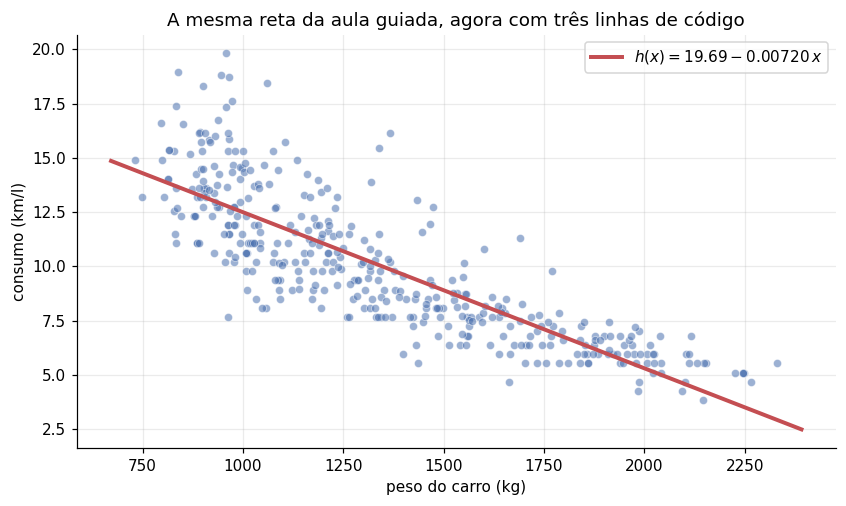

In [5]:
grade_x = np.linspace(X.min() - 60, X.max() + 60, 200).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(7.8, 4.7))
ax.scatter(X[:, 0], y, s=28, c=CORES[0], alpha=0.55, edgecolor="white", linewidth=0.5, zorder=3)
ax.plot(grade_x[:, 0], modelo.predict(grade_x), color=CORES[3], linewidth=2.6, zorder=4,
        label=fr"$h(x) = {modelo.intercept_:.2f} {modelo.coef_[0]:+.5f}\,x$")
ax.set_xlabel("peso do carro (kg)")
ax.set_ylabel("consumo (km/l)")
ax.set_title("A mesma reta da aula guiada, agora com três linhas de código")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 4. A API: `fit`, `predict`, `score`

Esta é a ideia mais valiosa do scikit-learn, e ela não tem nada a ver com regressão
linear: **todo** modelo da biblioteca expõe os mesmos três métodos.

| método | o que faz | equivalente na aula guiada |
|---|---|---|
| `fit(X, y)` | aprende os parâmetros a partir dos dados | `gradiente_descendente(...)` |
| `predict(X)` | devolve as previsões para novos exemplos | `hipotese(x, theta0, theta1)` |
| `score(X, y)` | uma medida de desempenho padrão | `r2_score(...)` |

Você já usou isso na aula 01, com `DecisionTreeClassifier` e `LogisticRegression`. É o
mesmo contrato. Trocar de algoritmo custa exatamente uma linha - a da criação do
estimador.

⚠️ Um detalhe que confunde: `score` devolve **coisas diferentes** para classificadores
e regressores. Em classificação é a **acurácia**; em regressão é o **$R^2$**. Faz
sentido - acurácia não existe quando o alvo é contínuo, como discutimos na aula guiada.

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

previsto = modelo.predict(X)

print(f"score(X, y) = {modelo.score(X, y):.6f}")
print(f"r2_score    = {r2_score(y, previsto):.6f}   <- é a mesma coisa")
print()
print(f"MAE  {mean_absolute_error(y, previsto):.3f} km/l")
print(f"RMSE {np.sqrt(mean_squared_error(y, previsto)):.3f} km/l")
print(f"R²   {r2_score(y, previsto):.3f}")

score(X, y) = 0.691793
r2_score    = 0.691793   <- é a mesma coisa

MAE  1.400 km/l
RMSE 1.842 km/l
R²   0.692


🔎 **PARE E PENSE**: esses três números foram calculados nos **mesmos dados** usados
para treinar. Depois de tudo que vimos na aula 01, quanta confiança eles merecem?

Para a regressão linear com um atributo, o risco é baixo: são dois parâmetros para 398
exemplos, e não há como decorar a base com uma reta. Mas o hábito de reportar o erro
de treino é péssimo, e a próxima seção conserta isso.

---
## 5. `StandardScaler`: o `padroniza` da biblioteca

O escore $z$ que você implementou está aqui, com outro nome. E a correspondência é
literal:

| você escreveu | scikit-learn |
|---|---|
| `padroniza(v)` → vetor, média, desvio | `StandardScaler().fit_transform(X)`, `mean_`, `scale_` |
| aplicar em dados novos com a média e o desvio guardados | `scaler.transform(X_novo)` |
| `desnormaliza(a0, a1, media, desvio)` | `scaler.inverse_transform(...)` (para os dados) |

In [7]:
from sklearn.preprocessing import StandardScaler

escalador = StandardScaler()
Xz = escalador.fit_transform(X)

print(f"mean_  = {escalador.mean_[0]:.4f}   (a nossa `media`)")
print(f"scale_ = {escalador.scale_[0]:.4f}   (o nosso `desvio`)")
print(f"\nX padronizado: média {Xz.mean():.2e}, desvio {Xz.std():.4f}")

# Confirmando que é exatamente a nossa fórmula
manual = (X - X.mean()) / X.std()
assert np.allclose(Xz, manual)
print("\nOK - StandardScaler é (v - média) / desvio, com desvio populacional.")

mean_  = 1347.3619   (a nossa `media`)
scale_ = 383.6381   (o nosso `desvio`)

X padronizado: média -4.64e-16, desvio 1.0000

OK - StandardScaler é (v - média) / desvio, com desvio populacional.


**`fit` e `transform` são passos separados, e isso é de propósito.** `fit` calcula a
média e o desvio; `transform` aplica. Você precisa dessa separação porque a média e o
desvio têm de vir **só do treino** - se você calculá-los usando o conjunto de teste,
informação do teste vaza para dentro do treinamento, e a sua estimativa de desempenho
fica otimista. É o mesmo argumento da imputação de valores ausentes na aula 01.

`fit_transform` é só um atalho para os dois de uma vez, e deve ser usado **apenas no
treino**. No teste, `transform` e nada mais.

🔎 **PARE E PENSE**: para a `LinearRegression`, padronizar não muda nada - o resultado
é exatamente o mesmo, porque ela resolve o sistema exatamente. Por que, então,
aprendemos normalização na aula guiada? (Se a resposta não vier, volte à seção 8.2:
o que aconteceu com $J$ quando usamos o peso em quilos?)

In [8]:
# A prova de que, aqui, padronizar não altera o resultado - só a escala dos coeficientes.
modelo_z = LinearRegression().fit(Xz, y)

print(f"sem padronizar:  intercept_ = {modelo.intercept_:8.4f}   coef_ = {modelo.coef_[0]:+.6f}")
print(f"padronizado:     intercept_ = {modelo_z.intercept_:8.4f}   coef_ = {modelo_z.coef_[0]:+.6f}")
print(f"\nPrevisões idênticas? {np.allclose(modelo.predict(X), modelo_z.predict(Xz))}")

# Desfazendo a padronização na mão, como na aula guiada
t1 = modelo_z.coef_[0] / escalador.scale_[0]
t0 = modelo_z.intercept_ - modelo_z.coef_[0] * escalador.mean_[0] / escalador.scale_[0]
print(f"\nDesnormalizando os coeficientes: theta0 = {t0:.4f}, theta1 = {t1:+.6f}")
assert np.isclose(t0, modelo.intercept_) and np.isclose(t1, modelo.coef_[0])
print("Confere com o modelo treinado sem padronizar.")

sem padronizar:  intercept_ =  19.6915   coef_ = -0.007195
padronizado:     intercept_ =   9.9971   coef_ = -2.760331

Previsões idênticas? True

Desnormalizando os coeficientes: theta0 = 19.6915, theta1 = -0.007195
Confere com o modelo treinado sem padronizar.


---
## 6. `Pipeline`: o pré-processamento junto do modelo

Se o pré-processamento tem de ser ajustado só no treino, e depois aplicado igual no
teste e em qualquer dado novo, é fácil errar: basta esquecer um `transform` ou trocar a
ordem. O `Pipeline` resolve isso amarrando as etapas num único estimador, que também
tem `fit`, `predict` e `score`.

In [9]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("escalador", StandardScaler()),
    ("regressor", LinearRegression()),
])
pipe.fit(X, y)

print(pipe)
print(f"\nR² = {pipe.score(X, y):.6f}")
print(f"Mesma previsão que o modelo simples? {np.allclose(pipe.predict(X), modelo.predict(X))}")

# Os passos ficam acessíveis pelo nome que você deu
print(f"\nmédia guardada no escalador do pipeline: {pipe.named_steps['escalador'].mean_[0]:.4f}")
print(f"coeficiente do regressor:                {pipe.named_steps['regressor'].coef_[0]:.4f}")

Pipeline(steps=[('escalador', StandardScaler()),
                ('regressor', LinearRegression())])

R² = 0.691793
Mesma previsão que o modelo simples? True

média guardada no escalador do pipeline: 1347.3619
coeficiente do regressor:                -2.7603


O ganho: quando você chama `pipe.fit(X_treino, y_treino)`, o escalador é ajustado
**só** no treino; quando você chama `pipe.predict(X_teste)`, ele apenas transforma. Não
há como esquecer, e não há como vazar. Daqui em diante, todo modelo desta disciplina
vai vir embrulhado num pipeline.

---
## 7. Treino e teste

Agora o que faltava: medir o desempenho em dados que o modelo nunca viu.

In [10]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)
print(f"treino: {X_treino.shape[0]} carros   |   teste: {X_teste.shape[0]} carros")

pipe.fit(X_treino, y_treino)

linhas = []
for nome, Xp, yp in [("treino", X_treino, y_treino), ("teste", X_teste, y_teste)]:
    pred = pipe.predict(Xp)
    linhas.append({
        "conjunto": nome,
        "MAE": mean_absolute_error(yp, pred),
        "RMSE": np.sqrt(mean_squared_error(yp, pred)),
        "R2": r2_score(yp, pred),
    })
print()
print(pd.DataFrame(linhas).set_index("conjunto").to_string(float_format=lambda v: f"{v:.4f}"))

reg = pipe.named_steps["regressor"]
esc = pipe.named_steps["escalador"]
print(f"\ncoeficiente aprendido só no treino, em unidades originais: "
      f"{reg.coef_[0] / esc.scale_[0]:+.6f} km/l por kg")
print(f"(com a base inteira era {modelo.coef_[0]:+.6f})")

treino: 298 carros   |   teste: 100 carros

            MAE   RMSE     R2
conjunto                     
treino   1.4224 1.8976 0.6804
teste    1.3651 1.6717 0.7277

coeficiente aprendido só no treino, em unidades originais: -0.007330 km/l por kg
(com a base inteira era -0.007195)


Treino e teste dão resultados parecidos - o que é o esperado para um modelo com dois
parâmetros. Uma reta não tem capacidade para decorar 298 carros; ela **não consegue**
sobreajustar aqui, nem se quisesse.

Guarde esse contraste: na aula 01, a árvore de decisão sem limite de profundidade
acertava 100% no treino e muito menos no teste. A diferença entre os dois modelos não é
a qualidade do código - é a **capacidade** do espaço de hipóteses.

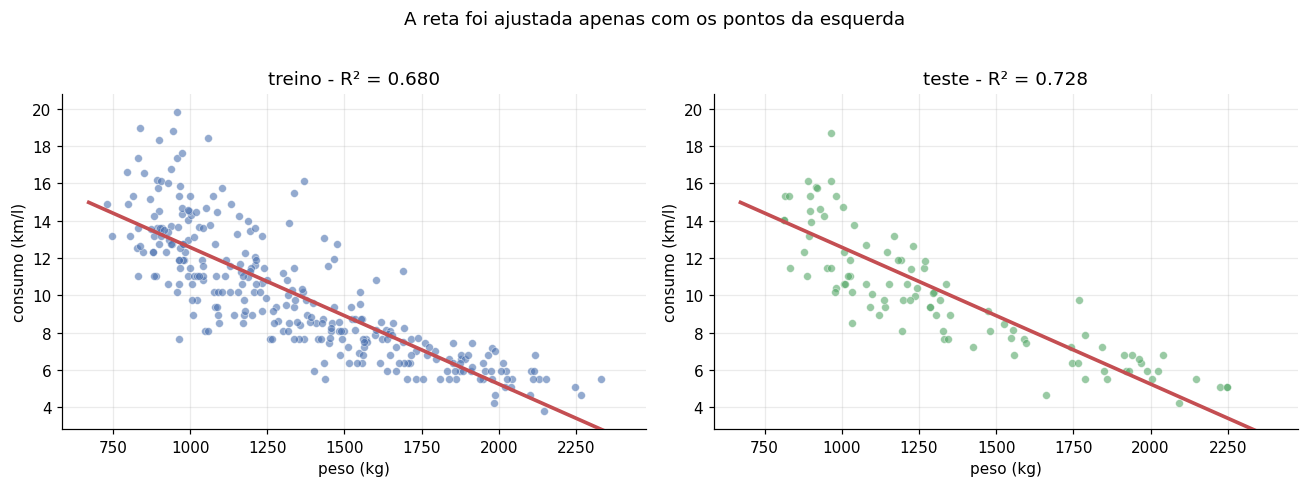

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

for ax, (nome, Xp, yp, cor) in zip(axes, [
    ("treino", X_treino, y_treino, CORES[0]),
    ("teste", X_teste, y_teste, CORES[2]),
]):
    ax.scatter(Xp[:, 0], yp, s=26, c=cor, alpha=0.6, edgecolor="white", linewidth=0.4, zorder=3)
    ax.plot(grade_x[:, 0], pipe.predict(grade_x), color=CORES[3], linewidth=2.4, zorder=4)
    ax.set_xlabel("peso (kg)"); ax.set_ylabel("consumo (km/l)")
    ax.set_title(f"{nome} - R² = {pipe.score(Xp, yp):.3f}")
    ax.set_ylim(y.min() - 1, y.max() + 1)

fig.suptitle("A reta foi ajustada apenas com os pontos da esquerda", y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Validação cruzada

O holdout acima usou **um** sorteio. A aula 01 mostrou o quanto essa loteria influencia
o resultado; a solução era o *k-fold*. Em regressão a ideia é idêntica - só as métricas
mudam.

In [12]:
from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
# Não existe versão "estratificada" para regressão: não há classes para estratificar.

resultado = cross_validate(
    Pipeline([("escalador", StandardScaler()), ("regressor", LinearRegression())]),
    X, y, cv=kf,
    scoring=["neg_mean_absolute_error", "neg_mean_squared_error", "r2"],
)

resumo = pd.DataFrame({
    "MAE": -resultado["test_neg_mean_absolute_error"],
    # a raiz é tirada fold por fold, para que a média abaixo seja a média dos RMSE
    "RMSE": np.sqrt(-resultado["test_neg_mean_squared_error"]),
    "R2": resultado["test_r2"],
})
resumo.index = [f"fold {i + 1}" for i in range(len(resumo))]
print(resumo.to_string(float_format=lambda v: f"{v:.4f}"))
print("\n" + "-" * 34)
print(f"{'média':>10}  " + "  ".join(f"{v:.4f}" for v in resumo.mean()))
print(f"{'desvio':>10}  " + "  ".join(f"{v:.4f}" for v in resumo.std()))

print(f"\nComo se reporta isso em um relatório:")
print(f"  MAE = {resumo['MAE'].mean():.2f} ± {resumo['MAE'].std():.2f} km/l "
      f"(10-fold CV)")
print(f"  R²  = {resumo['R2'].mean():.3f} ± {resumo['R2'].std():.3f}")

           MAE   RMSE     R2
fold 1  1.4297 1.8053 0.7061
fold 2  1.2082 1.4560 0.7461
fold 3  1.4538 1.7753 0.7231
fold 4  1.5010 1.8921 0.6507
fold 5  1.1814 1.5911 0.7190
fold 6  1.4271 1.9362 0.6575
fold 7  1.6985 2.3744 0.6513
fold 8  1.2252 1.8164 0.6672
fold 9  1.3611 1.8223 0.6853
fold 10 1.5294 1.8648 0.6782

----------------------------------
     média  1.4015  1.8334  0.6884
    desvio  0.1623  0.2389  0.0335

Como se reporta isso em um relatório:
  MAE = 1.40 ± 0.16 km/l (10-fold CV)
  R²  = 0.688 ± 0.033


⚠️ Repare no `neg_` dos nomes das métricas. O scikit-learn assume, em toda a
biblioteca, que **maior é melhor** - é o que permite que `GridSearchCV` e companhia
escolham o melhor modelo sem saber que métrica está sendo usada. Como o erro é o
contrário disso, ele é devolvido negativo, e cabe a você trocar o sinal.

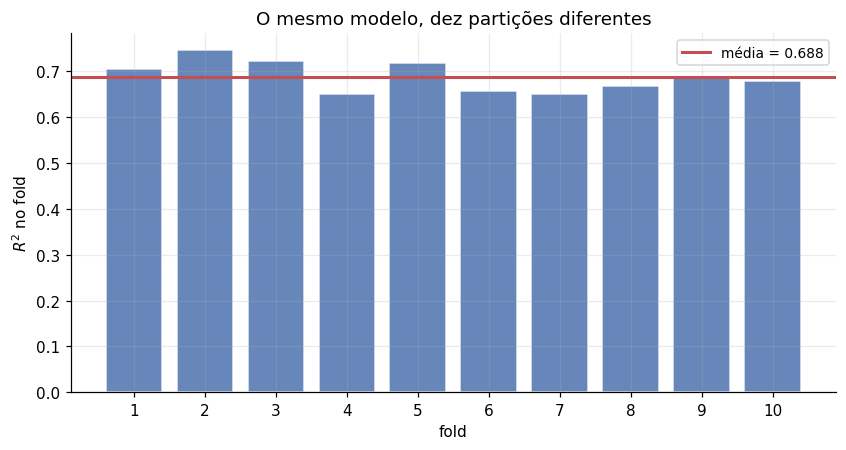

pior fold: 0.651   |   melhor fold: 0.746
Reportar apenas o melhor seria desonesto; reportar apenas um sorteio, sorte.


In [13]:
fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.bar(range(1, 11), resumo["R2"], color=CORES[0], alpha=0.85, edgecolor="white")
ax.axhline(resumo["R2"].mean(), color=CORES[3], linewidth=2,
           label=f"média = {resumo['R2'].mean():.3f}")
ax.set_xticks(range(1, 11))
ax.set_xlabel("fold"); ax.set_ylabel("$R^2$ no fold")
ax.set_title("O mesmo modelo, dez partições diferentes")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"pior fold: {resumo['R2'].min():.3f}   |   melhor fold: {resumo['R2'].max():.3f}")
print("Reportar apenas o melhor seria desonesto; reportar apenas um sorteio, sorte.")

---
## 9. `DummyRegressor`: a linha de base

Na aula 01, antes de comemorar a acurácia de um classificador, comparávamos com o
**erro majoritário** - prever sempre a classe mais frequente. Em regressão o
equivalente é **prever sempre a média**, e o scikit-learn tem um estimador para isso.

In [14]:
from sklearn.dummy import DummyRegressor

for nome, est in [
    ("prever sempre a média", DummyRegressor(strategy="mean")),
    ("prever sempre a mediana", DummyRegressor(strategy="median")),
    ("regressão linear", Pipeline([("e", StandardScaler()), ("r", LinearRegression())])),
]:
    r = cross_validate(est, X, y, cv=kf, scoring=["neg_mean_absolute_error", "r2"])
    print(f"{nome:>24}   MAE {-r['test_neg_mean_absolute_error'].mean():5.3f} km/l   "
          f"R² {r['test_r2'].mean():+.3f}")

print("\nO R² do baseline é ~0 por construção: R² compara justamente com a média.")

   prever sempre a média   MAE 2.780 km/l   R² -0.020
 prever sempre a mediana   MAE 2.776 km/l   R² -0.023


        regressão linear   MAE 1.402 km/l   R² +0.688

O R² do baseline é ~0 por construção: R² compara justamente com a média.


Repare que o $R^2$ do baseline não deu exatamente zero: deu **-0,02**. Isso não é erro
de arredondamento, e o motivo é instrutivo.

O `DummyRegressor` aprende a média do **treino** de cada fold, e é avaliado no
**teste** daquele fold - cuja média é ligeiramente diferente. Prever a média errada é
um pouco pior que prever a média certa, e $R^2$ registra isso como um valor negativo.

Um $R^2$ negativo, em geral, significa **pior que chutar a média** - e é mais comum do
que parece: acontece sempre que um modelo sobreajustado é levado a sério no teste.

---
## 10. `SGDRegressor`: o nosso laço, dentro da biblioteca

`LinearRegression` não itera. Mas o gradiente descendente que você implementou existe
no scikit-learn, no `SGDRegressor` - e agora todos os hiperparâmetros que você
escolheu na mão reaparecem com nomes próprios:

| você escreveu | `SGDRegressor` |
|---|---|
| `alfa` | `eta0` (com `learning_rate="constant"`) |
| `n_iter` | `max_iter` (uma passada por todos os exemplos = uma *época*) |
| "repetir até convergir" | `tol`, que para o treino quando a melhora fica pequena |
| o histórico de $J$ | não é guardado; vamos reconstruí-lo com `partial_fit` |

Uma diferença importante de vocabulário. O que implementamos foi o gradiente
descendente **em lote** (*batch*): cada passo olha **todos** os 398 carros. O `SGD` do
nome é *stochastic gradient descent*: cada passo olha **um** exemplo sorteado. É mais
barulhento, mas muito mais barato quando a base tem milhões de linhas - e o barulho,
na prática, ajuda a escapar de mínimos ruins em modelos mais complicados.

⚠️ Para o `SGDRegressor`, padronizar **não é opcional**: ele diverge exatamente como o
nosso código divergiu na seção 8.2 da aula guiada, e pelo mesmo motivo.

In [15]:
from sklearn.linear_model import SGDRegressor

# Reconstruindo a curva de convergência: uma época por chamada de partial_fit.
sgd = SGDRegressor(
    learning_rate="constant", eta0=0.0005,   # o nosso alfa
    penalty=None,                            # sem regularização (assunto de outra aula)
    max_iter=1, tol=None, random_state=RANDOM_STATE,
)

historico_J, historico_t0, historico_t1 = [], [], []
for epoca in range(40):
    sgd.partial_fit(Xz, y)                   # uma passada pelos 398 carros
    erros = sgd.predict(Xz) - y
    historico_J.append(erros @ erros / (2 * y.size))
    historico_t0.append(sgd.intercept_[0])
    historico_t1.append(sgd.coef_[0])

print(f"depois de 40 épocas:  theta0 = {sgd.intercept_[0]:.4f}   theta1 = {sgd.coef_[0]:.4f}")
print(f"o nosso laço achou:   theta0 = 9.9971            theta1 = -2.7603")
print(f"LinearRegression:     theta0 = {modelo_z.intercept_:.4f}            "
      f"theta1 = {modelo_z.coef_[0]:.4f}")
print(f"\nJ final = {historico_J[-1]:.4f}  (o mínimo é 1.6973)")

depois de 40 épocas:  theta0 = 10.0034   theta1 = -2.7653
o nosso laço achou:   theta0 = 9.9971            theta1 = -2.7603
LinearRegression:     theta0 = 9.9971            theta1 = -2.7603

J final = 1.6973  (o mínimo é 1.6973)


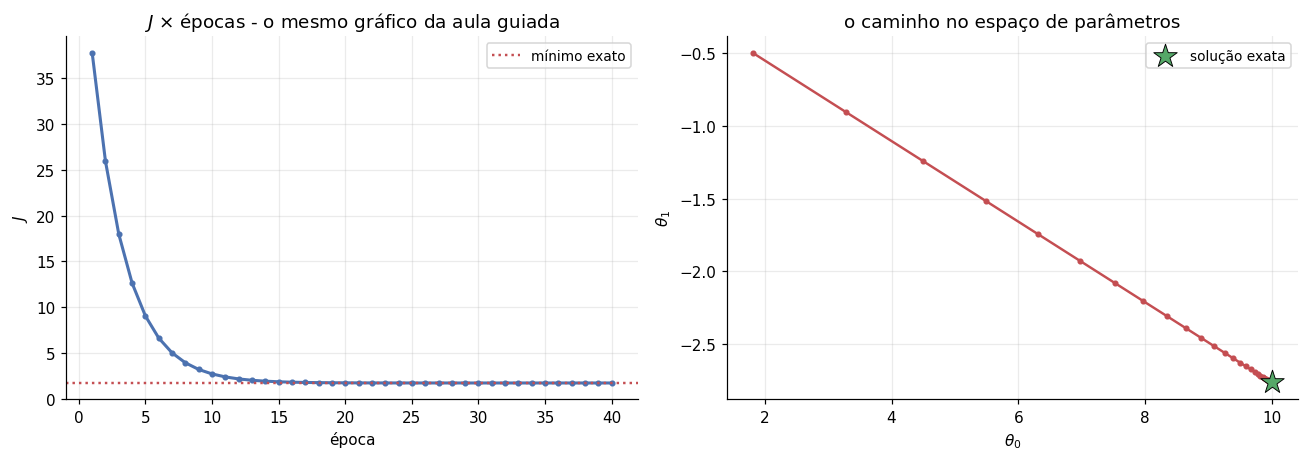

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

axes[0].plot(range(1, 41), historico_J, color=CORES[0], linewidth=2, marker="o", markersize=3)
axes[0].axhline(1.6973, color=CORES[3], linestyle=":", linewidth=1.6, label="mínimo exato")
axes[0].set_xlabel("época"); axes[0].set_ylabel(r"$J$")
axes[0].set_title(r"$J$ × épocas - o mesmo gráfico da aula guiada")
axes[0].legend(fontsize=9)

axes[1].plot(historico_t0, historico_t1, color=CORES[3], linewidth=1.6, marker="o", markersize=3)
axes[1].scatter([modelo_z.intercept_], [modelo_z.coef_[0]], marker="*", s=260,
                color=CORES[2], edgecolor="black", linewidth=0.6, zorder=5,
                label="solução exata")
axes[1].set_xlabel(r"$\theta_0$"); axes[1].set_ylabel(r"$\theta_1$")
axes[1].set_title("o caminho no espaço de parâmetros")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

🔎 **PARE E PENSE**: o `SGDRegressor` chegou a $\theta$ = (10,00; -2,77), e a solução
exata é (10,00; -2,76). Ele **não** acerta na mosca, e nunca vai - o passo estocástico
faz o parâmetro ficar oscilando em torno do mínimo em vez de assentar nele.

Sendo assim: por que alguém usaria `SGDRegressor` em vez de `LinearRegression`, se o
segundo é exato e não tem hiperparâmetro nenhum? (Duas pistas: pense numa base com
50 milhões de linhas, e pense em um modelo cuja função de custo não seja quadrática.)

---
## 11. Prevendo para carros novos

É para isso que se treina um modelo. O `predict` aceita qualquer `X` com o mesmo número
de colunas - e vale a pena passar um `DataFrame` com os nomes das colunas, para que a
própria biblioteca reclame se você trocar a ordem dos atributos.

In [17]:
pipe_final = Pipeline([("escalador", StandardScaler()), ("regressor", LinearRegression())])
pipe_final.fit(carros[["peso_kg"]], y)   # treinando com DataFrame, não com array

novos = pd.DataFrame({
    "peso_kg": [950.0, 1300.0, 1750.0, 2200.0, 4000.0],
}, index=["hatch compacto", "sedã médio", "SUV", "picape grande", "caminhonete pesada"])

novos["consumo_previsto_kml"] = pipe_final.predict(novos[["peso_kg"]])
print(novos.to_string(float_format=lambda v: f"{v:.2f}"))

print(f"\nFaixa de pesos usada no treinamento: {X.min():.0f} a {X.max():.0f} kg")

                    peso_kg  consumo_previsto_kml
hatch compacto       950.00                 12.86
sedã médio          1300.00                 10.34
SUV                 1750.00                  7.10
picape grande       2200.00                  3.86
caminhonete pesada  4000.00                 -9.09

Faixa de pesos usada no treinamento: 732 a 2331 kg


⚠️ Olhe a última linha: **-9,09 km/l**. Consumo negativo.

Os 4000 kg estão muito além dos 2331 kg do carro mais pesado da base - é uma
**extrapolação**. O modelo responde sem hesitar, sem emitir aviso nenhum, porque ele
não sabe que existe uma faixa em que foi treinado; ele é uma reta, e retas não têm
fronteira. Cabe a você conhecer o domínio dos seus dados.

🔎 **PARE E PENSE**: a partir de que peso este modelo passa a prever consumo negativo?
Resolva $\theta_0 + \theta_1 x = 0$ de cabeça, com $\theta_0 \approx 19{,}7$ e
$\theta_1 \approx -0{,}0072$.

O resultado é da ordem de 2700 kg - apenas ~400 kg acima do carro mais pesado que o
modelo viu. Não é um número absurdo, distante, teórico: é um utilitário grande. O
absurdo mora bem mais perto da faixa de treinamento do que a intuição sugere.

---
## 12. Salvando o modelo treinado

Um modelo treinado é um objeto Python com os parâmetros aprendidos dentro. Salvá-lo
em disco significa poder prever amanhã sem repetir o treinamento.

In [18]:
import joblib

joblib.dump(pipe_final, "modelo_consumo.joblib")
print(f"salvo: modelo_consumo.joblib "
      f"({Path('modelo_consumo.joblib').stat().st_size / 1024:.1f} KB)")

# Em outro programa, outro dia:
carregado = joblib.load("modelo_consumo.joblib")
print(f"\nprevisão para 1300 kg, modelo recarregado: "
      f"{carregado.predict(pd.DataFrame({'peso_kg': [1300.0]}))[0]:.2f} km/l")
assert np.allclose(carregado.predict(carros[["peso_kg"]]), pipe_final.predict(carros[["peso_kg"]]))
print("OK - o modelo carregado prevê exatamente o mesmo que o original.")

Path("modelo_consumo.joblib").unlink()   # limpando o arquivo de exemplo

salvo: modelo_consumo.joblib (1.3 KB)

previsão para 1300 kg, modelo recarregado: 10.34 km/l
OK - o modelo carregado prevê exatamente o mesmo que o original.


⚠️ Dois cuidados com arquivos `.joblib`: eles **não** são portáveis entre versões muito
diferentes do scikit-learn (guarde a versão junto), e carregar um arquivo desses
executa código - **nunca** abra um `.joblib` de origem desconhecida.

---
## 13. Fechamento: o dicionário

| o que você implementou | onde está no scikit-learn |
|---|---|
| `hipotese(x, theta0, theta1)` | `modelo.predict(X)` |
| `custo(x, y, theta0, theta1)` | `mean_squared_error(y, pred) / 2` |
| `gradiente(x, y, theta0, theta1)` | interno, não exposto |
| `gradiente_descendente(...)` | `SGDRegressor(...).fit(X, y)` |
| a solução fechada | `LinearRegression().fit(X, y)` |
| `padroniza(v)` | `StandardScaler()` |
| `normaliza_minmax(v)` | `MinMaxScaler()` |
| `desnormaliza(a0, a1, media, desvio)` | `scaler.inverse_transform`, ou a conta na mão |
| `theta0`, `theta1` | `modelo.intercept_`, `modelo.coef_` |
| `alfa`, `n_iter` | `eta0`, `max_iter` |
| encadear as etapas na mão | `Pipeline([...])` |
| prever sempre a média | `DummyRegressor(strategy="mean")` |

### O que fica

1. **A biblioteca não substitui o entendimento.** `eta0`, `max_iter` e a exigência de
   padronizar do `SGDRegressor` só fazem sentido para quem já viu $J$ explodir.
2. **`fit` / `predict` / `score` valem para tudo.** É o contrato de todos os
   estimadores - o que você aprendeu aqui serve para árvores, SVM e redes neurais.
3. **`Pipeline` não é organização, é correção.** Ele é o que garante que o
   pré-processamento seja ajustado só no treino.
4. **Sempre compare com uma linha de base.** Um $R^2$ de 0,69 só significa algo ao
   lado do 0,00 do `DummyRegressor`.

---
# 14. Exercícios

Todo o código já vem pronto: o trabalho é ler os resultados e explicar.

### Exercício 1 - A loteria do holdout

A célula abaixo repete o `train_test_split` 200 vezes, mudando apenas a semente.

**(a)** Qual foi o menor e o maior $R^2$ de teste? Qual a amplitude?

**(b)** Compare essa amplitude com o desvio padrão que a validação cruzada de 10 folds
reportou na seção 8. Por que a validação cruzada é uma estimativa mais estável?

**(c)** Se você quisesse "provar" que este modelo tem $R^2 = 0{,}75$, conseguiria
escolhendo a semente? Isso seria fraude ou apenas sorte? Onde está a linha?

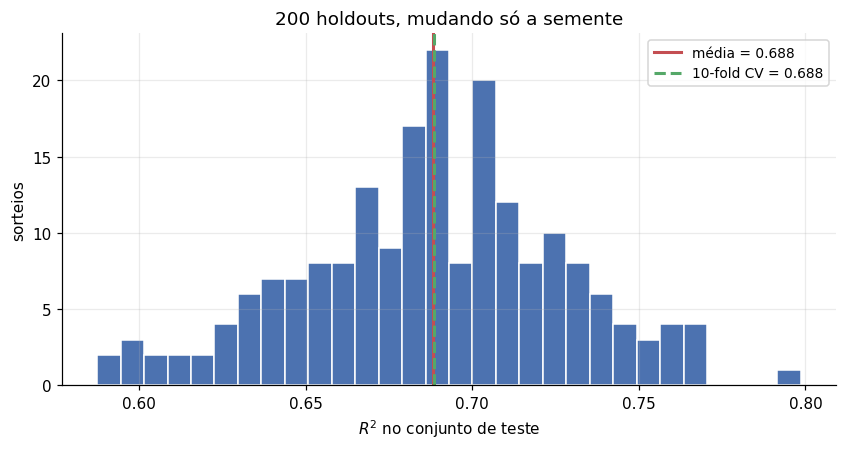

mínimo 0.588   máximo 0.799   amplitude 0.211
média 0.688 ± 0.039


In [19]:
r2s = []
for semente in range(200):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=semente)
    p = Pipeline([("e", StandardScaler()), ("r", LinearRegression())]).fit(Xtr, ytr)
    r2s.append(p.score(Xte, yte))
r2s = np.array(r2s)

fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.hist(r2s, bins=30, color=CORES[0], edgecolor="white")
ax.axvline(r2s.mean(), color=CORES[3], linewidth=2, label=f"média = {r2s.mean():.3f}")
ax.axvline(resumo["R2"].mean(), color=CORES[2], linewidth=2, linestyle="--",
           label=f"10-fold CV = {resumo['R2'].mean():.3f}")
ax.set_xlabel("$R^2$ no conjunto de teste"); ax.set_ylabel("sorteios")
ax.set_title("200 holdouts, mudando só a semente")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"mínimo {r2s.min():.3f}   máximo {r2s.max():.3f}   amplitude {np.ptp(r2s):.3f}")
print(f"média {r2s.mean():.3f} ± {r2s.std():.3f}")

**Respostas de (a) a (c):** *(escreva aqui)*

### Exercício 2 - Trocando o modelo em uma linha

A célula abaixo avalia quatro estimadores diferentes na **mesma** base, com o **mesmo**
código - só a linha que cria o modelo muda. Dois deles você ainda não estudou; trate-os
como caixas-pretas e olhe apenas os números.

**(a)** Qual modelo tem o melhor $R^2$ de validação cruzada? A diferença em relação à
regressão linear é grande?

**(b)** Olhe a coluna de $R^2$ **no treino** da árvore sem limite de profundidade.
Compare com o de teste. Que nome tem esse fenômeno?

**(c)** O `KNeighborsRegressor` prevê a média dos $k$ vizinhos mais próximos. Olhando o
gráfico, descreva com suas palavras a forma da função que ele aprendeu. Ela é uma
"reta"? É uma "função"?

**(d)** Se a regressão linear não é a melhor, por que gastamos uma aula inteira nela?

                   R2 treino  R2 teste (CV)  desvio
modelo                                             
média (baseline)      0.0000        -0.0199  0.0284
regressão linear      0.6919         0.6884  0.0318
árvore de decisão     0.9659         0.4087  0.1856
KNN (k=15)            0.7320         0.6971  0.0549


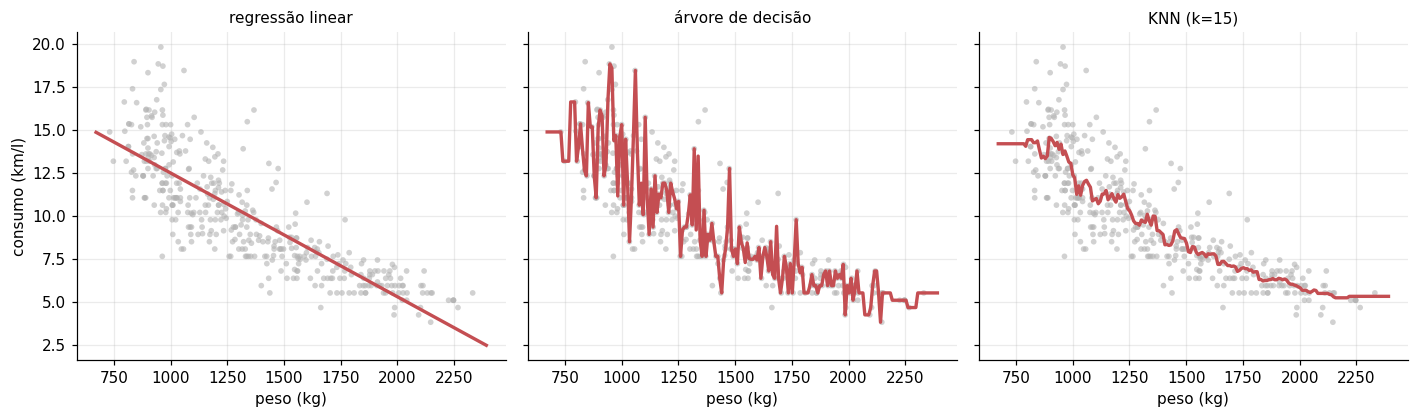

In [20]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

candidatos = {
    "média (baseline)": DummyRegressor(strategy="mean"),
    "regressão linear": LinearRegression(),
    "árvore de decisão": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "KNN (k=15)": KNeighborsRegressor(n_neighbors=15),
}

linhas = []
for nome, est in candidatos.items():
    p = Pipeline([("e", StandardScaler()), ("r", est)])
    cv = cross_validate(p, X, y, cv=kf, scoring="r2", return_train_score=True)
    linhas.append({"modelo": nome,
                   "R2 treino": cv["train_score"].mean(),
                   "R2 teste (CV)": cv["test_score"].mean(),
                   "desvio": cv["test_score"].std()})
print(pd.DataFrame(linhas).set_index("modelo").to_string(float_format=lambda v: f"{v:.4f}"))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.9), sharey=True)
for ax, nome in zip(axes, ["regressão linear", "árvore de decisão", "KNN (k=15)"]):
    p = Pipeline([("e", StandardScaler()), ("r", candidatos[nome])]).fit(X, y)
    ax.scatter(X[:, 0], y, s=14, c="0.7", alpha=0.6, edgecolor="none")
    ax.plot(grade_x[:, 0], p.predict(grade_x), color=CORES[3], linewidth=2.2)
    ax.set_title(nome, fontsize=10)
    ax.set_xlabel("peso (kg)")
axes[0].set_ylabel("consumo (km/l)")
plt.tight_layout()
plt.show()

**Respostas de (a) a (d):** *(escreva aqui)*

### Exercício 3 - Perguntas sobre a biblioteca

Sem código.

**(a)** Por que `coef_` termina em sublinhado e `max_iter`, não?

**(b)** Você tem 1000 exemplos e quer padronizar antes de treinar. Explique, em duas
frases, o que dá errado se você chamar `fit_transform` na base inteira antes de separar
treino e teste. O erro é grande neste caso concreto? E por que o hábito importa mesmo
quando o erro é pequeno?

**(c)** `LinearRegression` não tem `eta0` nem `max_iter`. Isso é uma limitação ou uma
vantagem? Em que situação você sentiria falta desses parâmetros?

**(d)** O `score` de um regressor devolve $R^2$; o de um classificador, acurácia. Se a
biblioteca sempre assume "maior é melhor", por que as métricas de erro aparecem com o
prefixo `neg_`?

**(e)** Volte à tabela da seção 13 e escolha a linha que você acha mais importante
lembrar dentro de um ano. Justifique em uma frase.

**Respostas de (a) a (e):** *(escreva aqui)*

---
## Referências

- PEDREGOSA, F. et al. Scikit-learn: machine learning in Python. *Journal of Machine
  Learning Research*, v. 12, p. 2825-2830, 2011.
- Guia do usuário do scikit-learn - *Linear Models*:
  <https://scikit-learn.org/stable/modules/linear_model.html>
- Guia do usuário do scikit-learn - *Preprocessing data*:
  <https://scikit-learn.org/stable/modules/preprocessing.html>
- Guia do usuário do scikit-learn - *Cross-validation*:
  <https://scikit-learn.org/stable/modules/cross_validation.html>
- GÉRON, A. *Hands-On Machine Learning with Scikit-Learn, Keras and TensorFlow*.
  3. ed. O'Reilly, 2022. (capítulos 2 e 4)